# Creates heatmaps, rasterplots and psths of Npx data

### Imports

In [30]:
import pynapple as nap
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns
import spikeinterface.full as si
import spikeinterface.postprocessing as spost
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import ListedColormap, BoundaryNorm

### Functions

In [122]:
def make_string(val):
    """Converts a list of strings into a single string."""
    if val is None:
        return None
    elif isinstance(val, list):
        return "_".join(str(x) for x in val) # If it's a list, join its elements with an underscore
    else:
        return val
    
def rescale_minus1to1(data):
    # Rescale values from -1 to 1 
    min_value = data.min()
    max_value = data.max()
    r_data = (2 * (data - min_value) / (max_value - min_value) - 1)
    r_data = np.nan_to_num(r_data, nan=0)
    return r_data

def smooth_tsd(curr_psth, sigma_bins=3):
    # Define your smoothing parameter (sigma in bins)
    # If bin_size = 0.01s (10ms), sigma = 3 gives a ~30ms Gaussian smoothing window
    
    # Smooth 
    smooth_psth = gaussian_filter1d(curr_psth, sigma=sigma_bins)

    # If pynapple object then wrap again times
    is_pynapple = isinstance(curr_psth, (nap.Tsd, nap.TsdFrame))
    if is_pynapple:
        smooth_psth = nap.Tsd(t=curr_psth.index, d=smooth_psth)
    return smooth_psth

def raster_psth_plot(curr_spikes_on, curr_stim_name, curr_cl, curr_stim_dur, curr_fr_psth, save_path=None, show_plot=True):
    # Notes: Index in curr_spikes_on is trial number, Index in counts is time and columns are trials 

    # Start Figure
    fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=[1, 0.3], figsize=(6, 6), gridspec_kw={"hspace": 0.15})

    # Plot rasterplot
    ax[0].plot(curr_spikes_on.to_tsd(), ".", markersize=3.5, color='black'); # Note: psth.to_tsd() gets spike times as index and a column indicating trial they belong to
    ax[0].set_xlabel("Time [s]", fontsize=12)
    ax[0].set_ylabel(f"Trials: {len(curr_spikes_on)}", fontsize=12)
    ax[0].set_title(f"Stim:{curr_stim_name}, Cluster:{curr_cl}", fontsize=12)
    ax[0].axvline(0, color="gray", linestyle="--", linewidth=1.5);
    ax[0].axvline(curr_stim_dur, color="gray", linestyle="--");
    ax[0].axvspan(0, curr_stim_dur, color='gray', alpha=0.2, ec='none');

    # Plot psth
    smooth_psth = smooth_tsd(curr_fr_psth, sigma_bins=2)
    ax[1].plot(smooth_psth, linewidth=1.5, color='black');
    ax[1].set_xlabel("Time [s]", fontsize=12)
    ax[1].set_ylabel("Firing Rate [Hz]", fontsize=12)
    ax[1].axvline(0, color="gray", linestyle="--", linewidth=1.5);
    ax[1].axvline(curr_stim_dur, color="gray", linestyle="--");
    ax[1].axvspan(0, curr_stim_dur, color='gray', alpha=0.2, ec='none');

    # Save plot
    if save_path is not None:
        save_name = f"{curr_stim_name}_cluster_{curr_cl}"
        plt.savefig(rf'{save_path}/{save_name}.png', bbox_inches='tight', dpi=300)
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig(rf'{save_path}/{save_name}.pdf', bbox_inches='tight')
    if show_plot:
        plt.show()
    plt.close(fig)

def plot_heatmap(psth, recording, curr_stim_name, curr_stim_dur, unit_type=None, roi=None, cell_type=None, exclude_zero_rows=True, bounded=None, save_path=None):
    """
    Function should be called once per stimulus, if psth contains many different ones, it wont work
    """

    # Plot heatmap
    data = np.array([psth[cl].values for cl in psth.keys()])
    print()
    if exclude_zero_rows:
    # Keep only rows that are not entirely zero
        mask = np.any(data != 0, axis=1)
        data = data[mask]

    first_index_psth = psth.index[0]
    time = psth[first_index_psth].index
    
    # Find time bin with max firing rate per cluster
    max_bins = np.argmax(data, axis=1)
    
    # Get indices to sort clusters by first max response 
    sorting_idx = np.argsort(max_bins) 
    
    # Sorted data
    sorted_data = data[sorting_idx]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    if bounded is not None:
        data_min = np.min(sorted_data)
        data_max = np.max(sorted_data)
        lower_bound = min(data_min - 1, bounded[0] - 1)
        upper_bound = max(data_max + 1, bounded[1] + 1)
        bounds = [lower_bound, bounded[0], bounded[1], upper_bound]
        norm = BoundaryNorm(bounds, ncolors=256)
        sns.heatmap(sorted_data, xticklabels=False, cmap="coolwarm", norm=norm, vmin=bounded[0], vmax=bounded[1], ax=ax)
    else:
        sns.heatmap(sorted_data, xticklabels=False, cmap="viridis", ax=ax)

    # Plot onset and offset lines
    on_idx = np.argmin(np.abs(time - 0)) # Find index of value closest to 0
    curr_stim_dur_ix = np.argmin(np.abs(time - curr_stim_dur)) # Find index of value closest to curr_stim_dur
    ax.axvline(on_idx, color="gray", linestyle="--", linewidth=1.5);
    ax.axvline(curr_stim_dur_ix, color="gray", linestyle="--");
    #ax.axvspan(on_idx, curr_stim_dur_ix, color='gray', alpha=0.2, ec='none');

    # Plot ticks
    x_ticks_indices = np.arange(0, sorted_data.shape[1], 10)
    x_ticks_labels = time[x_ticks_indices]
    x_ticks_labels = [f"{x:.1f}" for x in time[x_ticks_indices]]
    ax.set_xticks(x_ticks_indices)
    ax.set_xticklabels(x_ticks_labels, rotation=90)
    ax.xaxis.tick_bottom()

    # Plot labels
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.set_xlabel("Time (s)");
    ax.set_ylabel(f"Clusters {len(data)}");
    ax.set_title(f"{recording} - {curr_stim_name}");

    # Save plot
    if save_path is not None:
        str_parts = [make_string(unit_type), make_string(roi), make_string(cell_type)]
        cltype = "_".join(p for p in str_parts if p is not None)
        save_name = f"{recording}_{curr_stim_name}_{cltype}"
        plt.savefig(rf'{save_path}/{save_name}.png', bbox_inches='tight', dpi=300)
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig(rf'{save_path}/{save_name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Define paths and recording to access

In [41]:
#######################
## User Input ##
#######################

# Parameters relative to Npx neural data
recording = "M296_3_g0"
ap_folder = Path(rf'M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0')
ks_folder = Path(rf"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0\kilosort4")
analyzer_path = ks_folder / 'waveform' # If there is no analyzer, write None
phy_done = True

# Parameters relative to stims (stimulation pulses) data
stim_path = fr"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0"
stim_file_name = f"plbs_seconds_summary_M296_3_13_07_26_13_37_exp_summary_updated.csv"
stim_durations = {'DC_M296_1_n':0.110, 'DC_M296_2_n':0.220, 'DC_F502_1_n':0.164, 'DC_F502_2_n':0.232, 'BOSM296_n':1.526, 'BOSM296_2_n':1.110, 'StF307':0.109, 'StJ':0.105}

# Parameters of units to analyze
unit_type = ["good", "mua"]
roi = "hvc"
cell_type = None

# Analysis parameters
run_analysis = True
save_data = True
stims_type = 'plbs'

#######################
## End of User Input ##
#######################

## Data analysis

### Load data

In [34]:
# Create recording object
ap_rec = si.read_spikeglx(ap_folder, stream_name='imec0.ap');

# Create or if existing, load sorting object
sorting_path = Path(ks_folder / 'waveform' / 'sorting')

if sorting_path.is_dir():
    sorting = si.load(ks_folder / 'waveform' / 'sorting')
else:
    # If curation in phy is done use read_phy, otherwise read_kilosort
    if phy_done:
        sorting = si.read_phy(folder_path=ks_folder)
    else:
        sorting = si.read_kilosort(folder_path=ks_folder);

# Create or if existing, load analyzer object
if analyzer_path is None:
    analyzer = si.create_sorting_analyzer(sorting, ap_rec, format="binary_folder", folder= ks_folder / 'waveform', overwrite=True, **global_job_kwargs);
else:
    analyzer = si.load_sorting_analyzer(analyzer_path)

#### **Spikes**

In [35]:
# Get spike times and corresponding clusters
np_clusters = np.load(ks_folder / "spike_clusters.npy")
spikes_fs = sorting.get_sampling_frequency()
np_spikes = np.load(ks_folder / "spike_times.npy")/spikes_fs # spike_times are in samples, should be transformed to spike times seconds

# Load data needed to filter - q_group, roi, cell_type
np_clusters_info = pd.DataFrame(sorting.get_property('q_group'), index=sorting.get_unit_ids(), columns=['q_group'])
np_clusters_info.index.name = 'cluster_id'
np_clusters_info['roi'] = sorting.get_property('roi')
np_clusters_info['cell_type'] = sorting.get_property('cell_type')

# Sanity Check - Evaluate if column cluster_id corresponds to ids in np_clusters
cluster_ids = np_clusters_info.index.to_numpy()
unique_clusters = np.unique(np_clusters)

only_in_info = np.setdiff1d(cluster_ids, unique_clusters)
only_in_clusters = np.setdiff1d(unique_clusters, cluster_ids)

print("In clusters.npy but NOT in cluster_ids from sorting object")
print(only_in_info)

print("In cluster_ids from sorting object but NOT in clusters.npy")
print(only_in_clusters)

## Filter data: Choose clusters to keep and build spikes object
if roi is not None:
    unit_mask = ((np.isin(np_clusters_info['q_group'], unit_type)) & (np.isin(np_clusters_info['roi'], roi)))
else:
    unit_mask = np.isin(np_clusters_info['q_group'], unit_type)
    roi = ["no_roi"]

if (len(unit_type) == 1) & (unit_type[0] == "good"):
    unit_mask = ((np.isin(np_clusters_info['q_group'], unit_type)) & (np.isin(np_clusters_info['roi'], roi)) & (np.isin(np_clusters_info['cell_type'], cell_type)))    
elif (len(unit_type) > 1) & (cell_type is not None):
    print("Uncompatible unit_types selected for desired cell_type")
    
# Filter clusters and spikes to keep only relevant clusters
clusters2pick = cluster_ids[unit_mask]
cluster_mask = np.isin(np_clusters, clusters2pick)
filtered_clusters = np_clusters[cluster_mask]
filtered_spikes = np_spikes[cluster_mask]

# Construct pynapple object with spike times and cluster ids
## Using to_tsgroup() sorts data by cluster, assigning spikes to clusters
spikes = nap.Tsd(t=filtered_spikes.ravel(), d=filtered_clusters).to_tsgroup()

In clusters.npy but NOT in cluster_ids from sorting object
[]
In cluster_ids from sorting object but NOT in clusters.npy
[]


Index for spikes is cluster id

#### **Playbacks**

In [37]:
# Access stims data
stim_file = Path(stim_path, stim_file_name)
stims_df = pd.read_csv(stim_file)

# Get times and stimuli labels from df
stims_df = stims_df[stims_df['order'] == 'onset'] # Think about not using anymore offsets in csv file
stim_times = stims_df["s_timesP"].values
stim_names = stims_df["s_names"].values

# Transform stim_names to numbers
encoder = LabelEncoder()
stim_idx = encoder.fit_transform(stim_names)

# Construct tsd group for stimuli 
stims = nap.Tsd(t=stim_times, d=stim_idx).to_tsgroup()
stims["stim_name"] = encoder.classes_
stims["stim_dur"] = np.array([stim_durations[name] for name in encoder.classes_])

Index for stims is stim encoded number that maps to labels in stim_name

### Process data

In [45]:
if run_analysis:

    ## Get spikes_on object dict with one entry per cluster, and each entry is a tsd group
    # Initialize bundle to wrap all data
    psth_bundle = {}
    # Loop over stims 
    for idx, curr_stim_df in stims.metadata.iterrows():
        curr_stim = stims[idx]
        curr_stim_name = curr_stim_df['stim_name']
        curr_stim_dur = curr_stim_df['stim_dur']
        spikes_window = [-.505, curr_stim_df['stim_dur'] + 1]
        spikes_on = nap.compute_perievent(data=spikes, events=curr_stim, window=(spikes_window))

        # Get spikes on baseline window
        baseline_window = [spikes_window[0] - 0.5, 0] # Pynapple forces 2nd element to be positive []
        spikes_baseline = nap.compute_perievent(data=spikes, events=curr_stim, window=(baseline_window))

        # Restrict baseline time to desired window [needed when window is in negative values]
        baseline_interval = nap.IntervalSet(start=baseline_window[0], end=spikes_window[0])
        for cluster_id in spikes_baseline.keys():
            spikes_baseline[cluster_id] = spikes_baseline[cluster_id].restrict(baseline_interval)
        print(f'Current stimulus: {curr_stim_name}, Number of clusters: {len(spikes_on.keys())}')

        # Loop over clusters - Get fr, fr_baseline, zfr_th, zfr, fr_mean and scaled_fr [-1,1]
        bin_size = 0.01
        # Start dicts to keep data for each cluster wrapped - Keys in dicts are cluster number, and each cell is a tsd
        fr_dict = {}
        scaled_fr_dict = {}
        zfr_th_dict = {}
        zfr_dict = {}
        for curr_cluster in spikes_on.keys():
            curr_spikes_on = spikes_on[curr_cluster]
            curr_spikes_baseline = spikes_baseline[curr_cluster]
    
            # Bin spikes and get fr considering bin_size
            trial_fr = curr_spikes_on.count(bin_size).values / bin_size
            trial_fr_baseline = curr_spikes_baseline.count(bin_size).values / bin_size
    
            # Get firing rate across trials for current cluster - fr binned
            spike_counts = curr_spikes_on.count(bin_size) # Just to have timestamps needed for tsd
            spike_counts_baseline = curr_spikes_baseline.count(bin_size) # Just to have timestamps needed for tsd
            fr = np.mean(trial_fr, axis=1)
            fr_baseline = np.mean(trial_fr_baseline, axis=1)
            fr = nap.Tsd(t=spike_counts.t, d=fr)
            fr_baseline = nap.Tsd(t=spike_counts_baseline.t, d=fr_baseline)
    
            # Get mean of fr and fr_baseline
            trial_mean_baseline = np.mean(trial_fr_baseline, axis=0) # by trials, across time 
            mean_fr = np.mean(fr) # across time and trials
            mean_baseline = np.mean(fr_baseline) # across time and trials
            std_baseline = np.std(fr_baseline) # across trials
    
            # Get z score - handle when std = 0
            # Formula applies only when baseline-stimulus data are paired by trial
            diff_per_trial = trial_fr - trial_mean_baseline
            mean_diff = np.mean(diff_per_trial, axis=1)
            std_diff = np.std(diff_per_trial, axis=1)
            zfr_th = np.zeros_like(mean_diff)
            valid_bins = std_diff > 0
            zfr_th[valid_bins] = mean_diff[valid_bins] / std_diff[valid_bins]
            zfr_th = nap.Tsd(t=spike_counts.t, d=zfr_th)
        
            # Alternative simple z score
            if std_baseline == 0:
                zfr = np.zeros_like(fr)
            else:
                zfr = (fr - mean_baseline) / std_baseline
    
            # Rescale firing rate to values between -1 and 1
            scaled_fr = rescale_minus1to1(fr)

            # Collect variables calculated in the loop 
            fr_dict[curr_cluster] = fr
            scaled_fr_dict[curr_cluster] = scaled_fr
            zfr_th_dict[curr_cluster] = zfr_th
            zfr_dict[curr_cluster] = zfr
        
        # Transform dicts into tsGroups
        fr_psth = nap.TsGroup(fr_dict)
        scaled_psth = nap.TsGroup(scaled_fr_dict)
        zfr_th_psth = nap.TsGroup(zfr_th_dict)
        zfr_psth = nap.TsGroup(zfr_dict)

        # Add current psth groups with all associated clusters into a dict - keys are stim_names    
        psth_bundle[curr_stim_name] = {'spikes_on': spikes_on, 'fr_psth': fr_psth, 'scaled_psth': scaled_psth,
            'zfr_th_psth': zfr_th_psth, 'zfr_psth': zfr_psth, 'recording':recording, 'stim_name':curr_stim_name,
            'stim_dur':curr_stim_dur, 'unit_type':unit_type, 'roi':roi, 'cell_type':cell_type}    

    # Save psth bundle
    if save_data:
        str_parts = [make_string(stims_type), make_string(unit_type), make_string(roi), make_string(cell_type)]
        cltype = "_".join(p for p in str_parts if p is not None)
        output_filename = f"{recording}_{cltype}_psth_bundle.pkl"
        pickle_full_path = Path(ks_folder) / output_filename
        with open(pickle_full_path, "wb") as f:
            pickle.dump(psth_bundle, f)
        print(f"Data saved: {pickle_full_path}")
    else:
        print(f"Data not saved")
    
# If analysis is not run, then load analysis data
else:
    str_parts = [make_string(stims_type), make_string(unit_type), make_string(roi), make_string(cell_type)]
    cltype = "_".join(p for p in str_parts if p is not None)
    output_filename = f"{recording}_{stims_type}_{cltype}_psth_bundle.pkl"
    pickle_full_path = Path(ks_folder) / output_filename
    with open(pickle_full_path, "rb") as f:
        psth_bundle = pickle.load(f)
    print(f"Data loaded: {pickle_full_path}")

Current stimulus: BOSM296_2_n, Number of clusters: 130
Current stimulus: BOSM296_n, Number of clusters: 130
Current stimulus: DC_F502_1_n, Number of clusters: 130
Current stimulus: DC_F502_2_n, Number of clusters: 130
Current stimulus: DC_M296_1_n, Number of clusters: 130
Current stimulus: DC_M296_2_n, Number of clusters: 130
Current stimulus: StF307, Number of clusters: 130
Current stimulus: StJ, Number of clusters: 130
Data saved: M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0\kilosort4\M296_3_g0_plbs_good_mua_hvc_psth_bundle.pkl


Index in _psth variables is cluster number

## Plots

### Heatmap (scaled -1, +1)

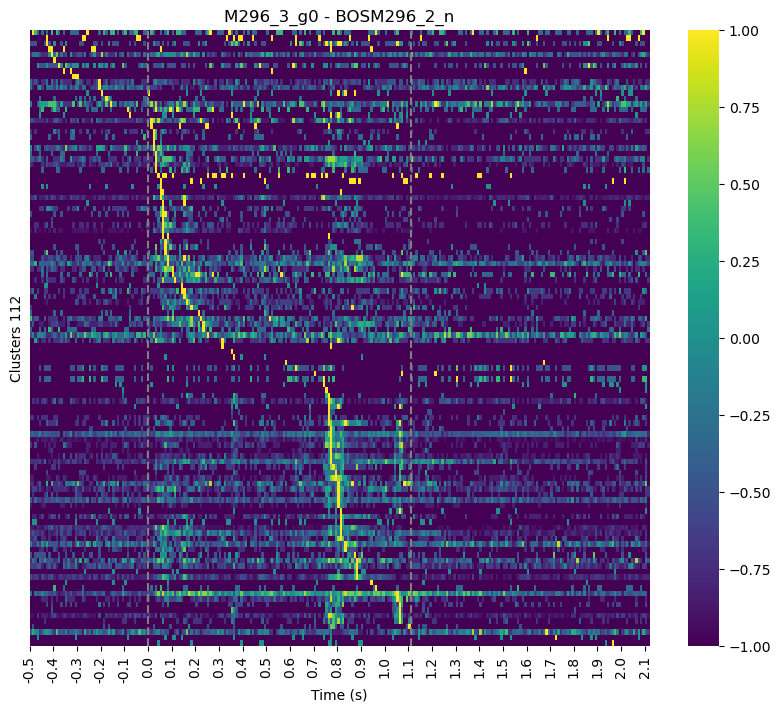

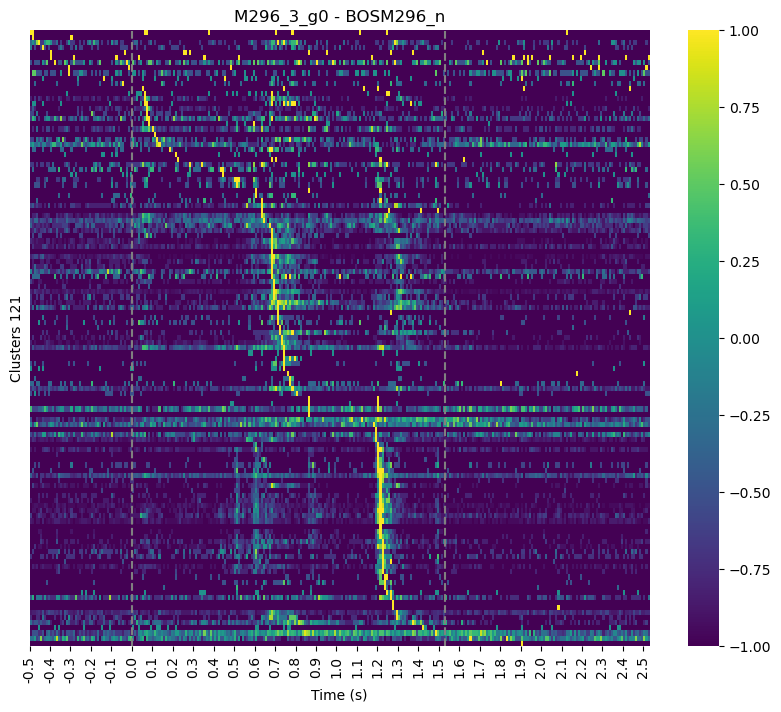

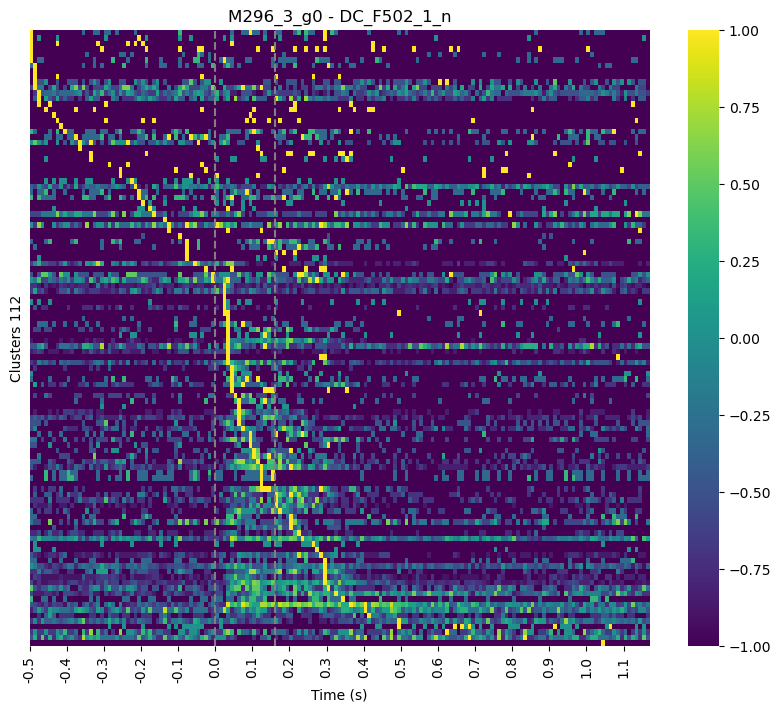

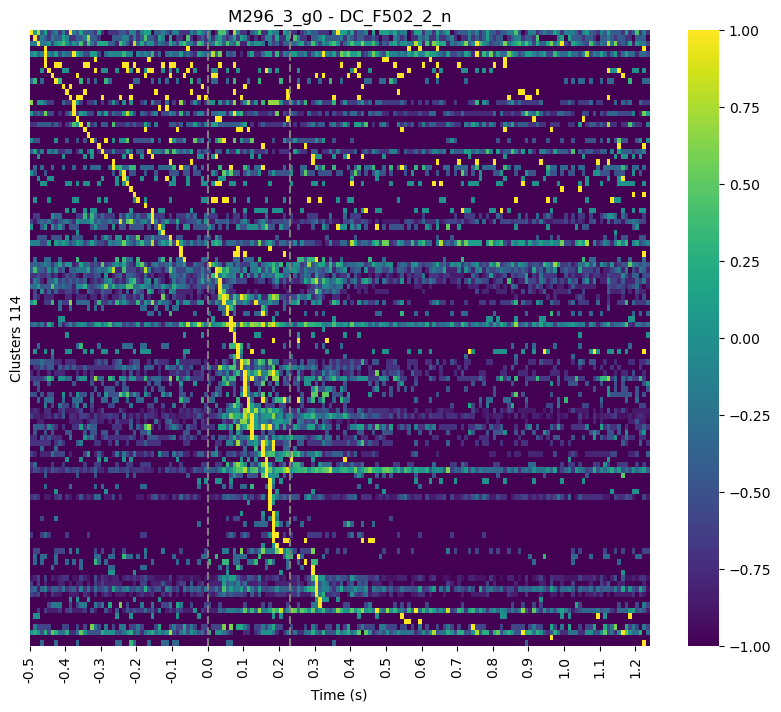

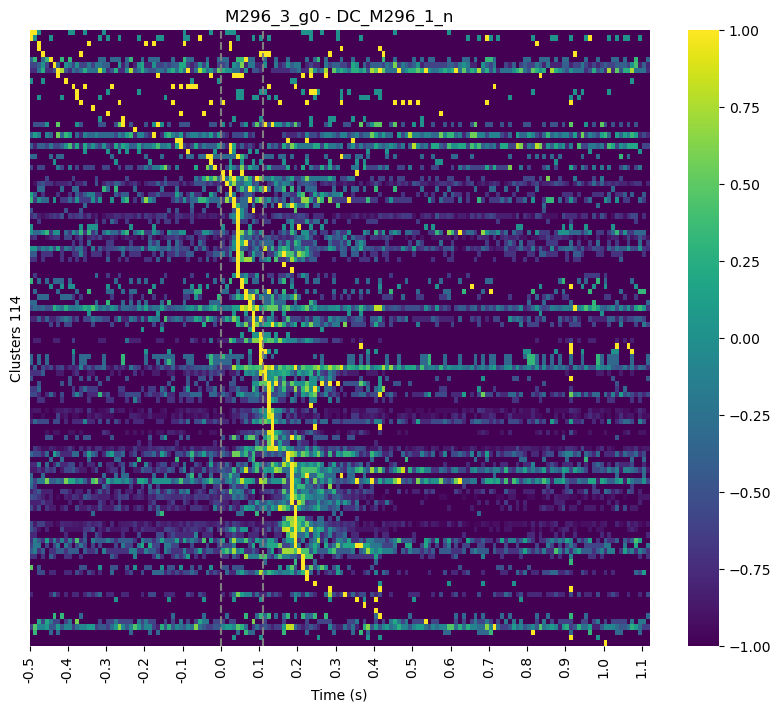

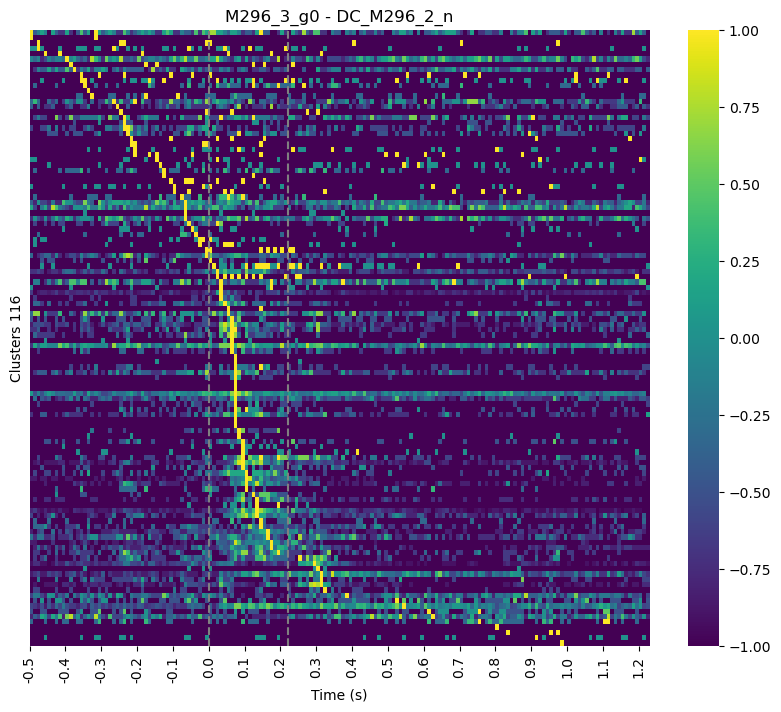

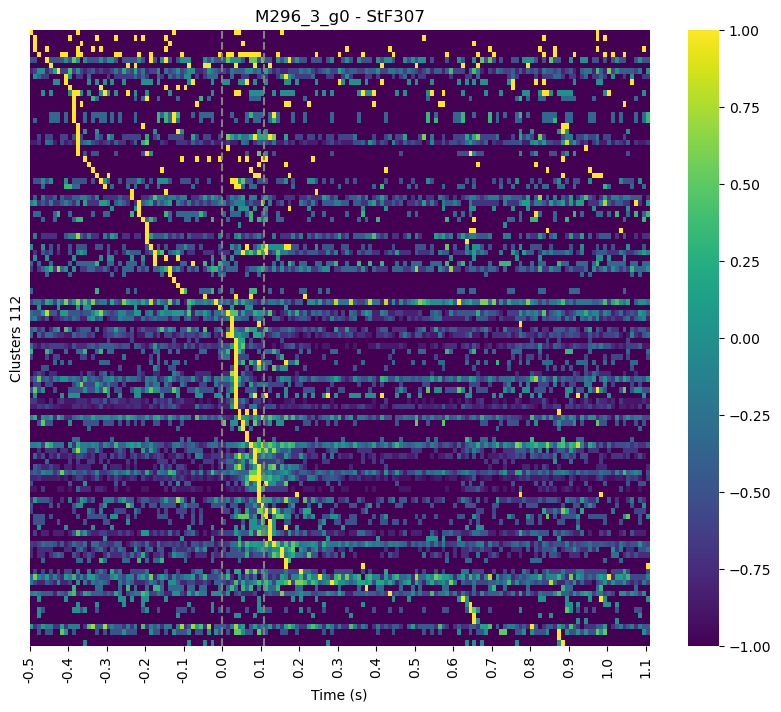

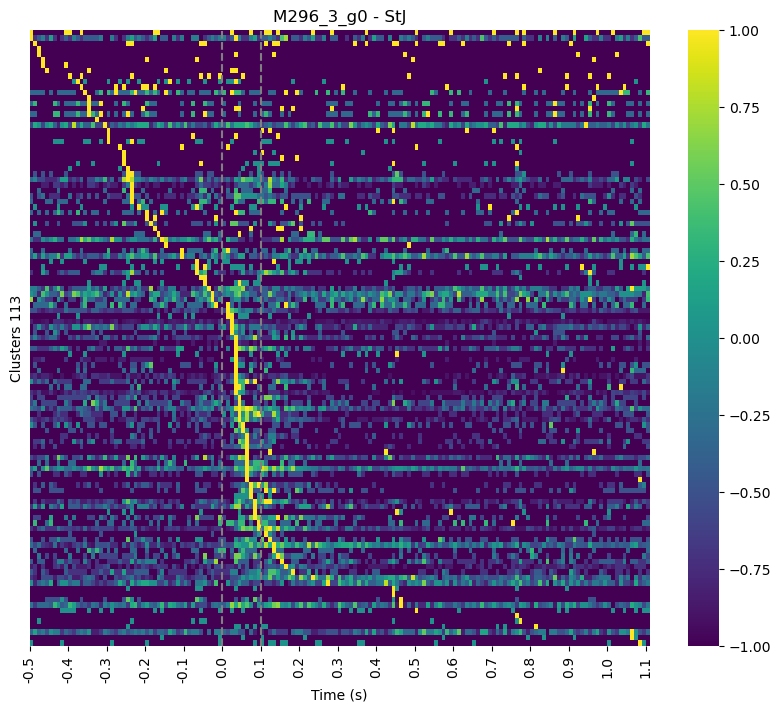

In [123]:
# Create folder to save plots
heatmap_scaled_fpath = ks_folder / f"heatmap_scaled_{stims_type}"

# Check if folder exists, otherwise create one 
heatmap_scaled_fpath.mkdir(exist_ok=True)

# Loop over stims
for curr_stim_name, curr_dict in psth_bundle.items():
    scaled_psth = curr_dict['scaled_psth']
    # Plot rescaled heatmaps sorted by first max peak
    plot_heatmap(scaled_psth, curr_dict['recording'], curr_stim_name, curr_dict['stim_dur'], curr_dict['unit_type'],
             curr_dict['roi'], curr_dict['cell_type'], exclude_zero_rows=True, save_path=heatmap_scaled_fpath)

## PSTH (z score relative to baseline)

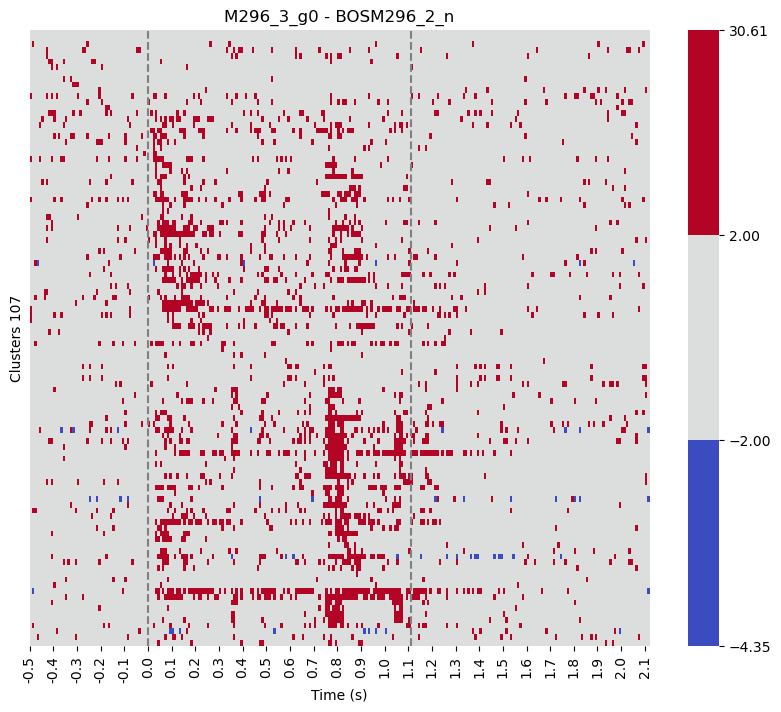

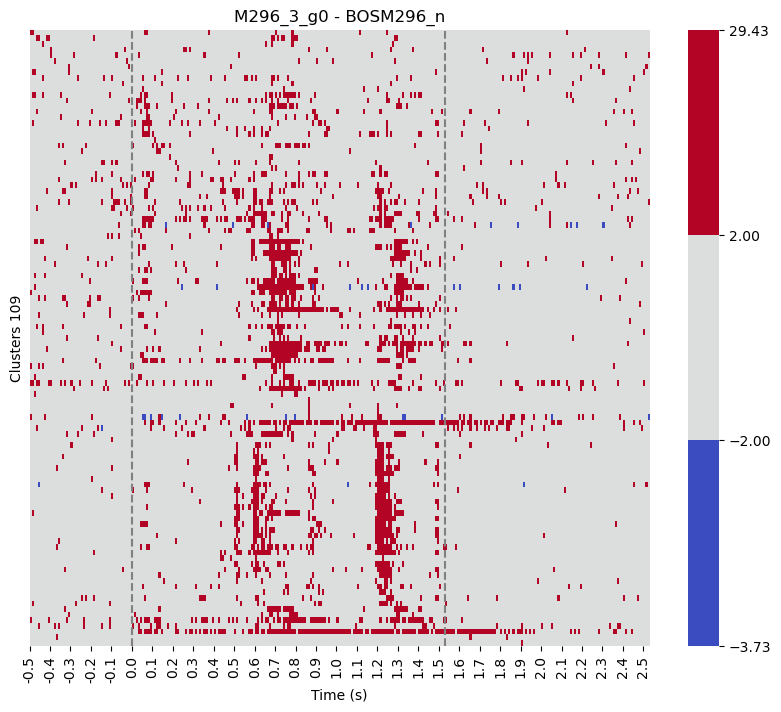

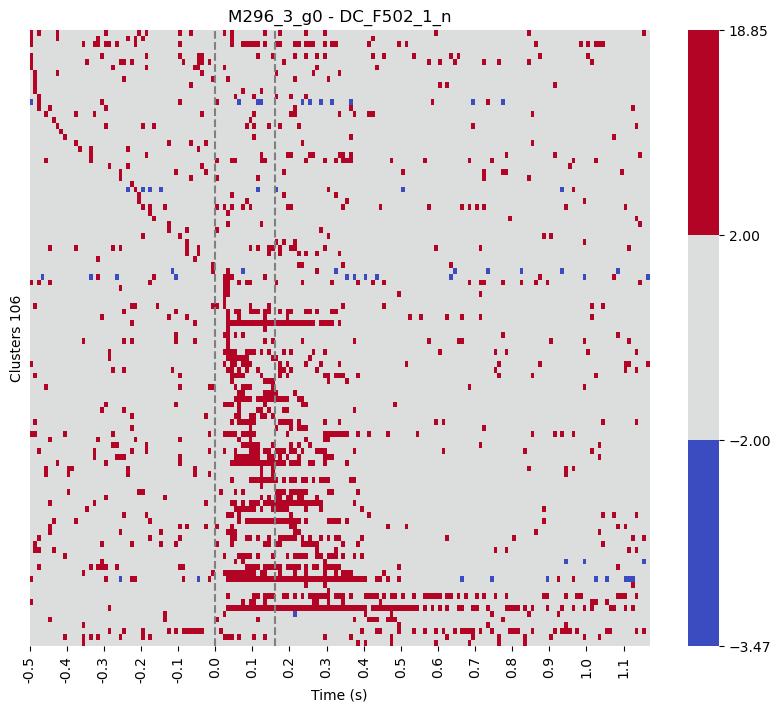

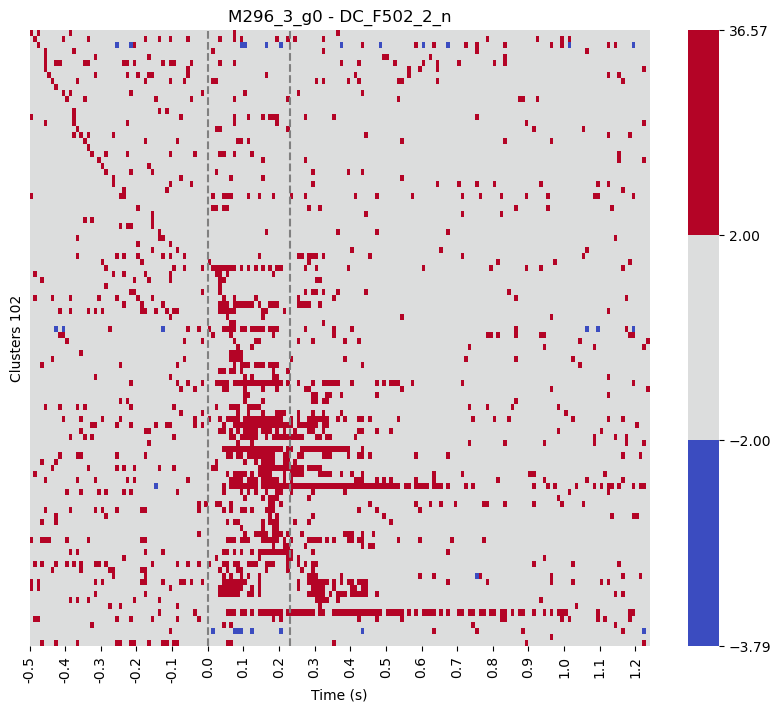

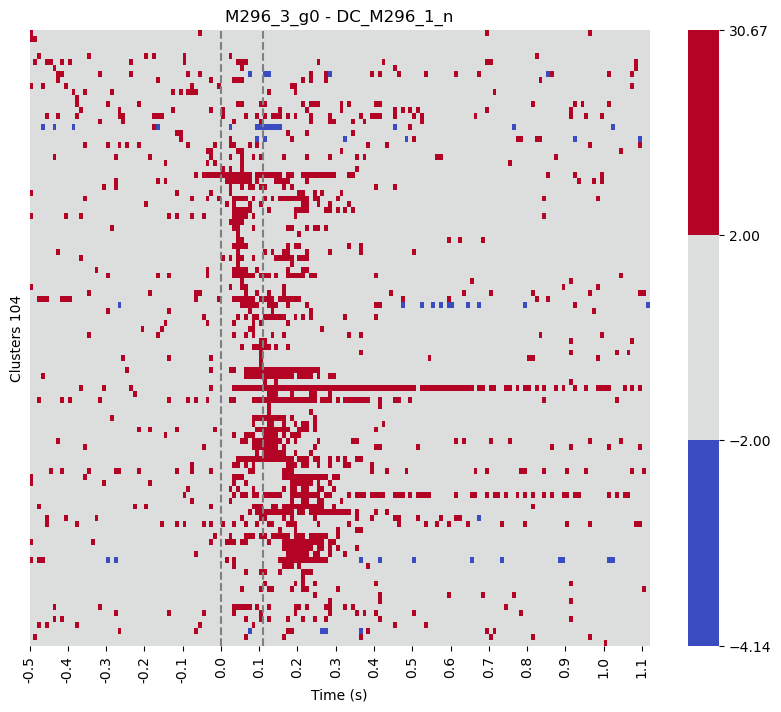

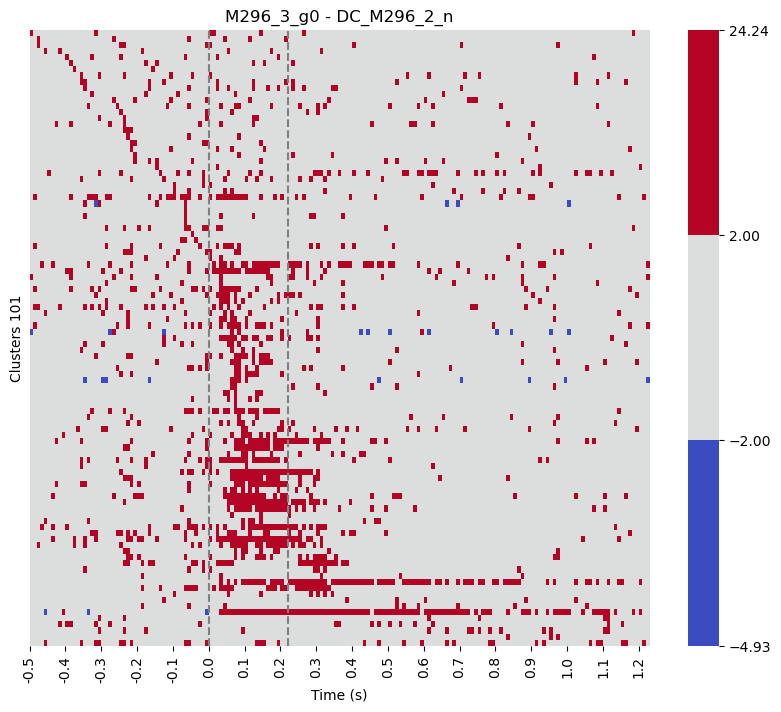

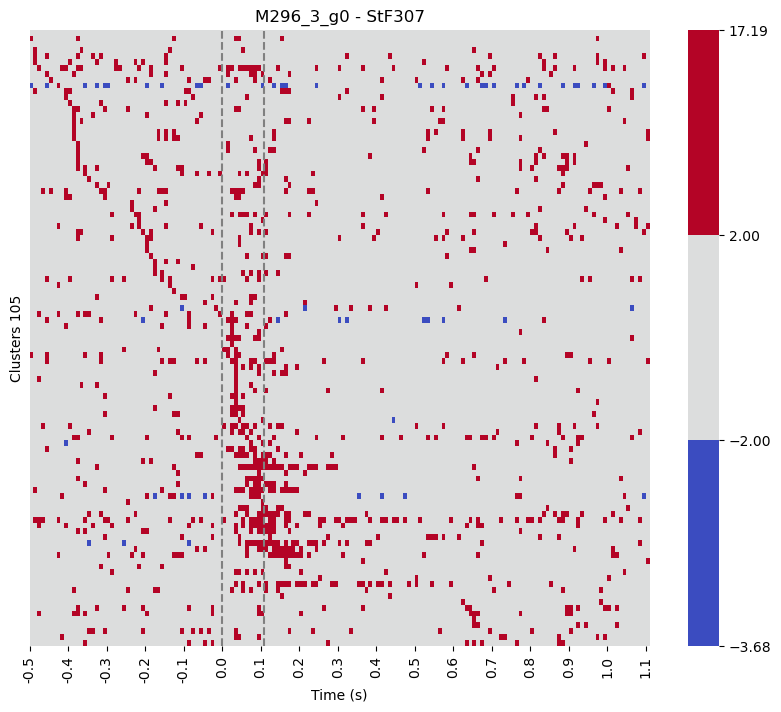

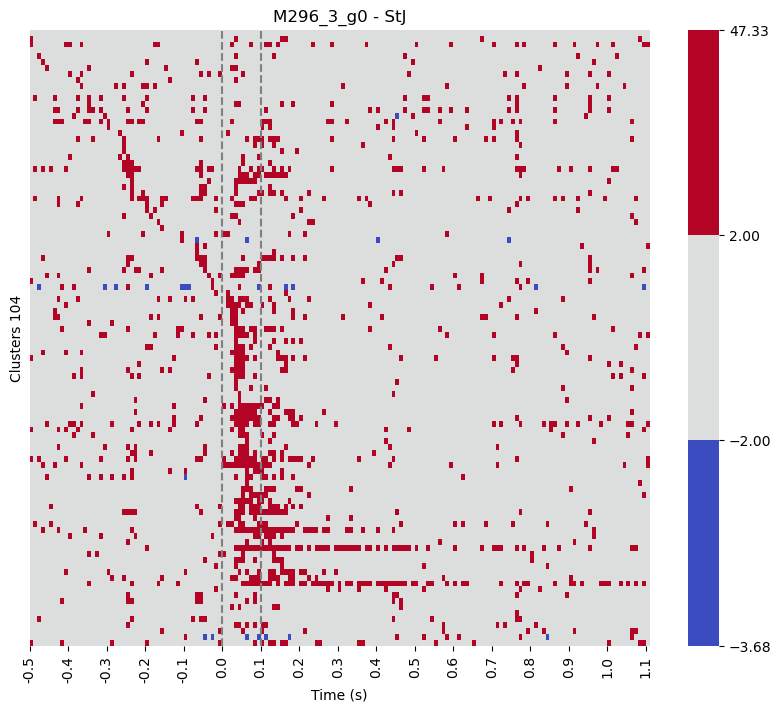

In [124]:
# Create folder to save plots
heatmap_zscore_fpath = ks_folder / f"heatmap_zscore_{stims_type}"

# Check if folder exists, otherwise create one 
heatmap_zscore_fpath.mkdir(exist_ok=True)

# Loop over stims
for curr_stim_name, curr_dict in psth_bundle.items():
    zfr_psth = curr_dict['zfr_psth']
    # Plot z score heatmaps sorted by first max peak
    plot_heatmap(curr_dict['zfr_psth'], curr_dict['recording'], curr_stim_name, curr_dict['stim_dur'], curr_dict['unit_type'],
             curr_dict['roi'], curr_dict['cell_type'], exclude_zero_rows=True, bounded=[-2,2], save_path=heatmap_zscore_fpath)

## Event, Rasterplot, PSTH plot

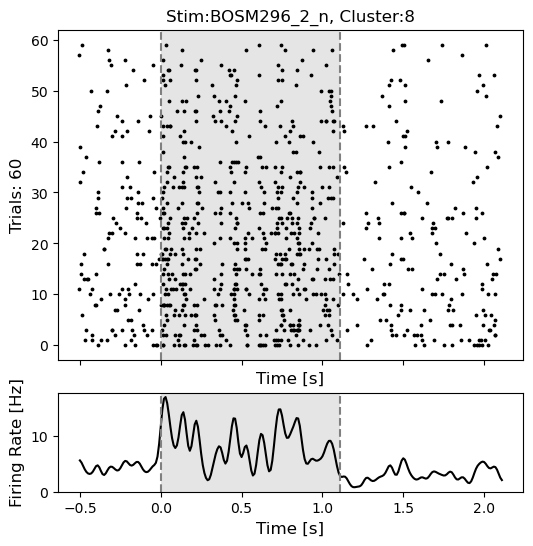

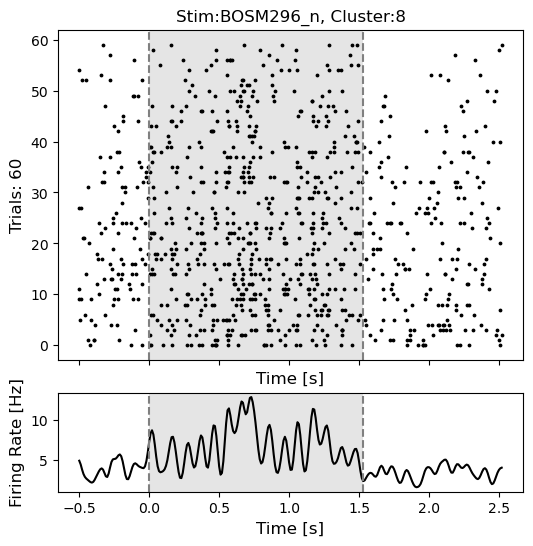

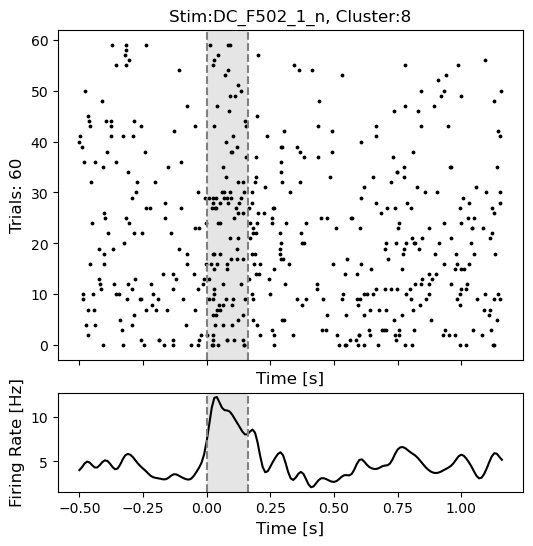

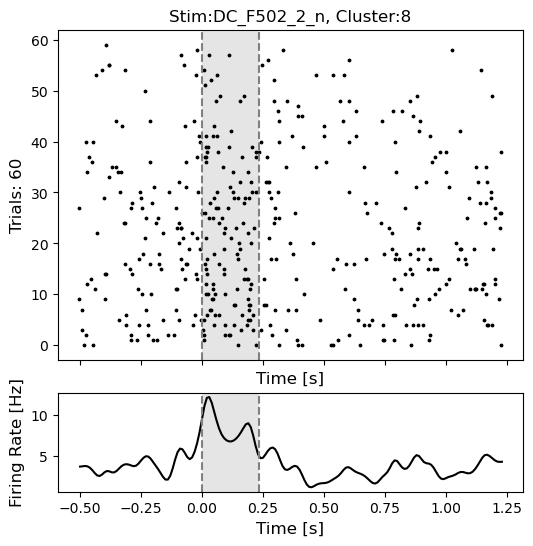

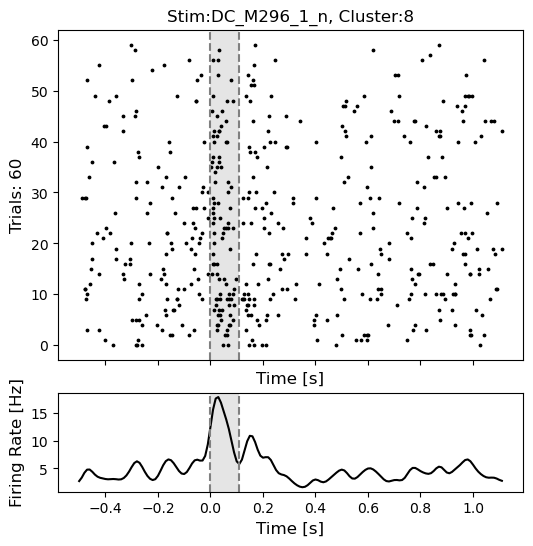

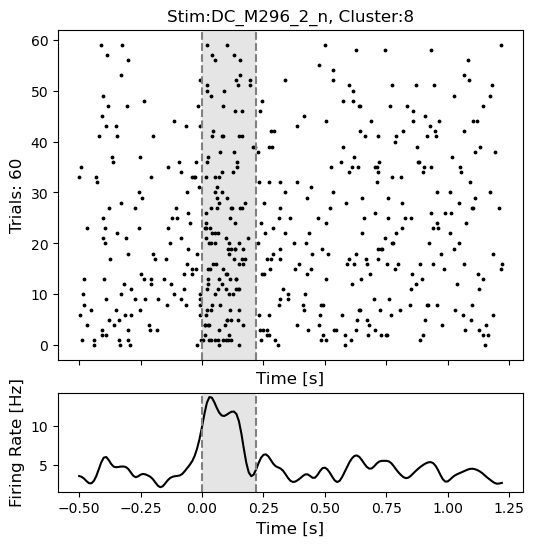

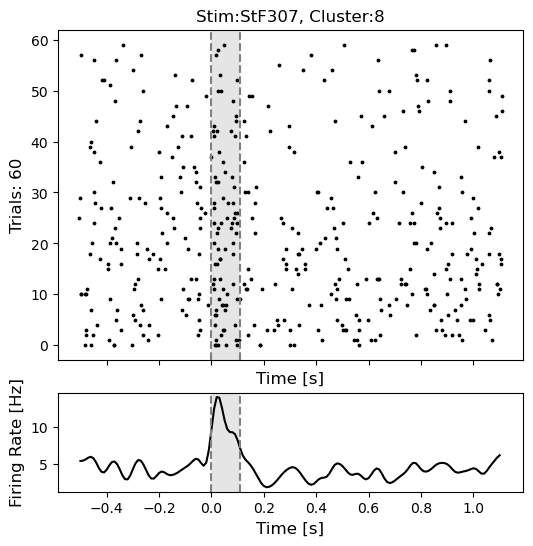

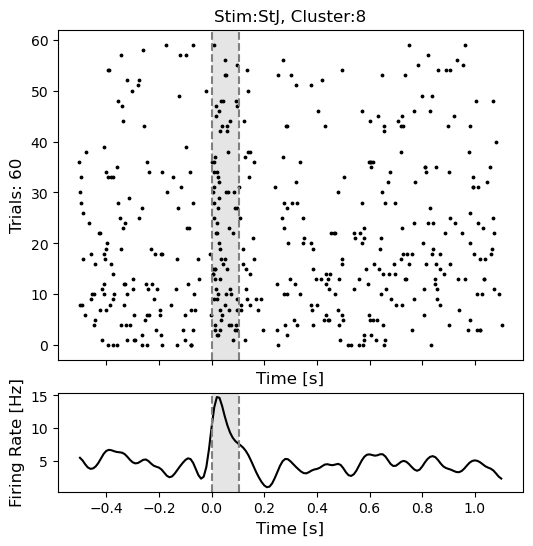

In [125]:
# Create folder to save plots
str_parts = [make_string(stims_type), make_string(unit_type), make_string(roi), make_string(cell_type)]
cltype = "_".join(p for p in str_parts if p is not None)
psth_fpath = ks_folder / f"psth_{cltype}"

# Check if folder exists, otherwise create one 
psth_fpath.mkdir(exist_ok=True)

# Loop over stims
for curr_stim_name, curr_dict in psth_bundle.items():
    curr_spikes_on = curr_dict['spikes_on']
    curr_fr_psth = curr_dict['fr_psth']
    # Loop over clusters
    for e, curr_cluster in enumerate(curr_dict['spikes_on'].keys()):
        # Plot psths
        show_plot = True if e == 0 else False
        raster_psth_plot(curr_spikes_on[curr_cluster], curr_stim_name, curr_cluster, curr_dict['stim_dur'], curr_fr_psth[curr_cluster], save_path=psth_fpath, show_plot=show_plot)

JUST ADD Spectrogram to playback plot, and fix sorting so it starts from 0 and not from first negative value. 

FIN